# **Подготовка данных**

В задании используется база курса акций Лукойла.

1. Обучите простую полносвязную сеть для прогнозирования временного ряда (только close) и визуализируйте результат.

2. Обучите такую же архитектуру сети на прогнозирование на 10 шагов вперёд прямым способом и визуализируйте результат.

3. Постройте графики сравнения предсказания с оригинальным сигналом по всем 10 шагам предсказания (10 графиков на разных отдельных осях).

4. Сделайте те же задания с другой сетью, которая будет использовать Conv1D или LSTM слои.



In [1]:
import sys
import subprocess

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'yfinance'], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, LSTM, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


# Основные настройки
TICKER = 'LKOH.ME'
START_DATE = '2010-01-01'
CSV_FILE = '1luk.csv'

win_len = 30
batch_size = 32


# Скачивание котировок и сохранение цены закрытия в CSV
def download_close_series(ticker, start_date, file_name):
    quotes = yf.download(ticker, start=start_date)

    if isinstance(quotes.columns, pd.MultiIndex):
        close_series = quotes[('Close', ticker)]
    else:
        close_series = quotes['Close']

    close_table = close_series.to_frame(name='CLOSE')
    close_table.to_csv(file_name)

    print(f'Данные скачаны и сохранены в {file_name}')
    return close_table


# Загрузка сохранённого файла
def load_price_array(file_name):
    source = pd.read_csv(file_name, sep=',')
    return source['CLOSE'].values.reshape(-1, 1)

def scale_values(values):
    normalizer = StandardScaler()
    scaled_values = normalizer.fit_transform(values)
    return scaled_values, normalizer

def make_one_step_generators(values_scaled, window, batch):
    border = int(len(values_scaled) * 0.8)

    train_generator = TimeseriesGenerator(
        values_scaled,
        values_scaled,
        length=window,
        batch_size=batch,
        end_index=border
    )

    test_generator = TimeseriesGenerator(
        values_scaled,
        values_scaled,
        length=window,
        batch_size=batch,
        start_index=border
    )

    return train_generator, test_generator, border


download_close_series(TICKER, START_DATE, CSV_FILE)

data = load_price_array(CSV_FILE)
data_scaled, scaler = scale_values(data)

train_gen, test_gen, train_len = make_one_step_generators(
    data_scaled,
    win_len,
    batch_size
)

/tmp/ipykernel_2944/1107127586.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  quotes = yf.download(ticker, start=start_date)
[*********************100%***********************]  1 of 1 completed

Данные скачаны и сохранены в 1luk.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0548
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0070
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0029
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036
Epoch 9/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0033
Epoch 10/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0065
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


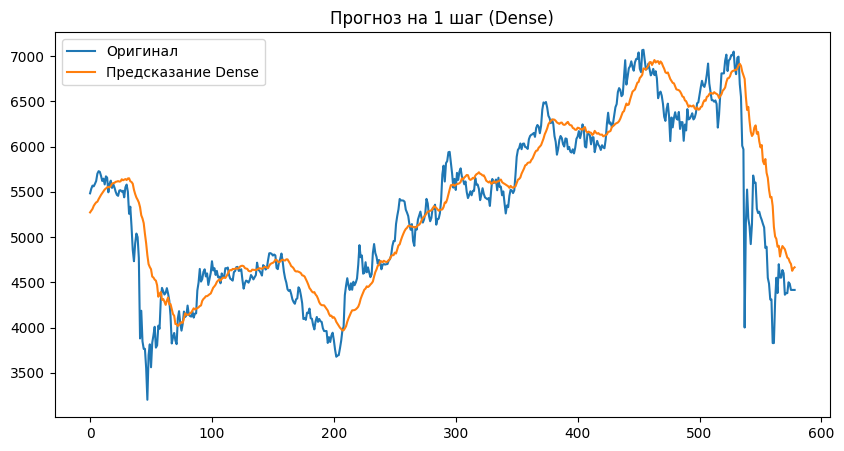

In [2]:
# Модель для прогноза цены на один день вперёд
def build_dense_forecaster(window):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(window, 1)),
        Flatten(),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model


# Построение графика фактических и предсказанных значений
def show_single_step_forecast(real_values, predicted_values):
    plt.figure(figsize=(10, 5))
    plt.plot(real_values, label='Оригинал')
    plt.plot(predicted_values, label='Предсказание Dense')
    plt.title('Прогноз на 1 шаг (Dense)')
    plt.legend()
    plt.show()


model_dense = build_dense_forecaster(win_len)
model_dense.fit(train_gen, epochs=10)

dense_predictions = model_dense.predict(test_gen)

y_true = data[train_len + win_len:]
y_pred = scaler.inverse_transform(dense_predictions)

show_single_step_forecast(y_true, y_pred)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0316
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0030
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0030
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0026
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025
Epoch 9/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023
Epoch 10/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 11/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023
Epoch 12/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026
Epoch 13/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 14/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054
Epoch 15/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020
18/18 ━━━━━━━━━━━━━━━━━━━━

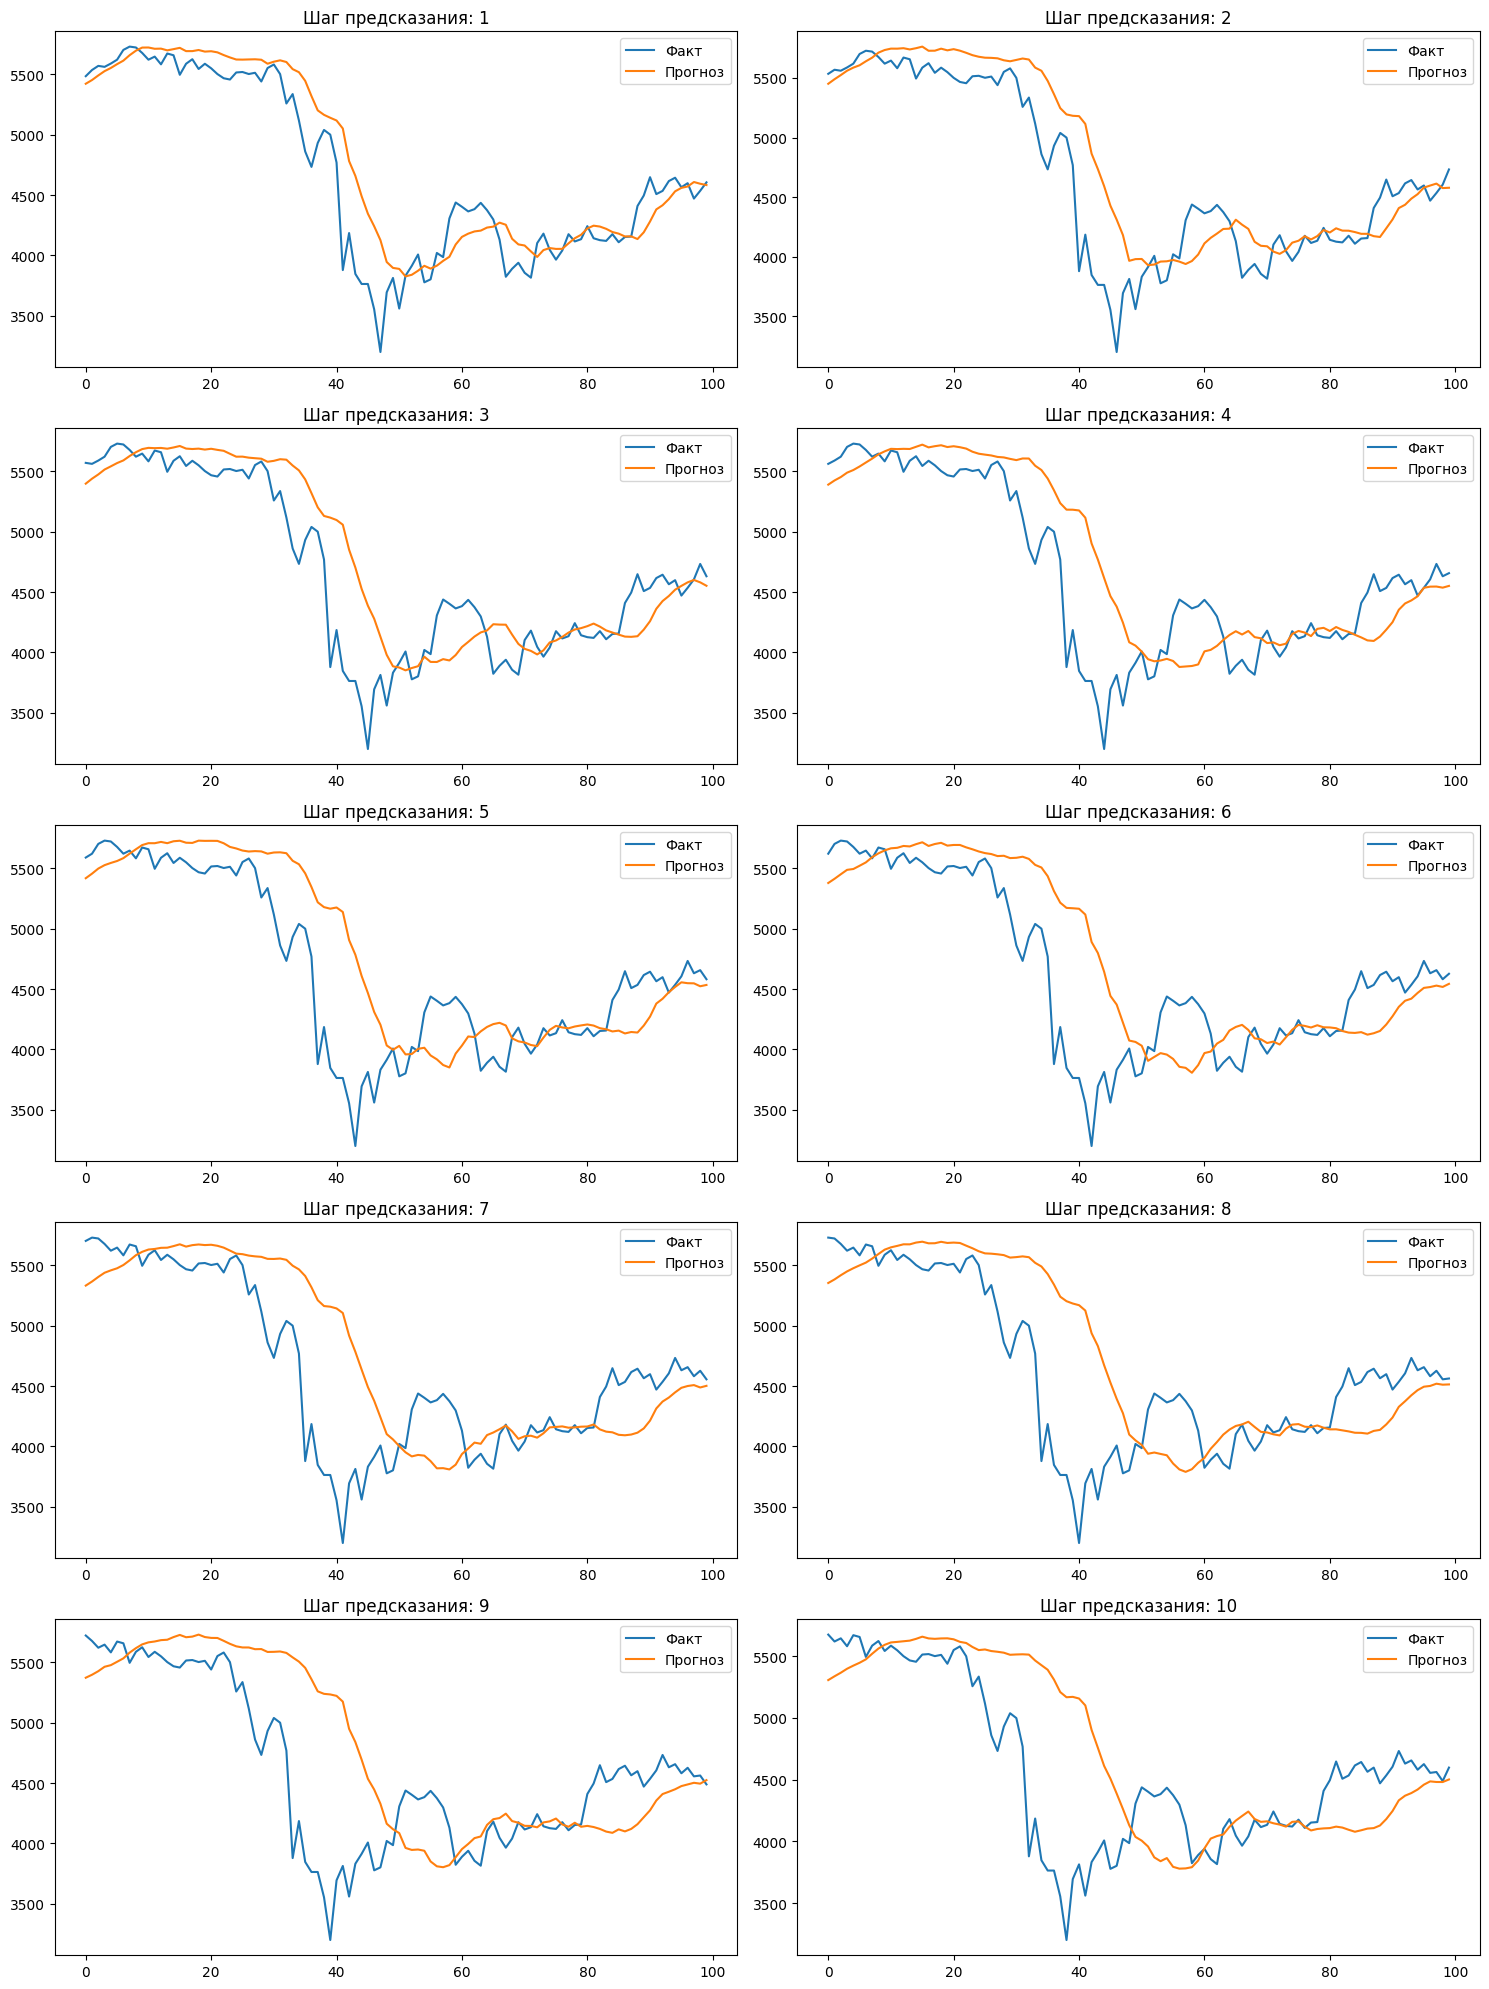

In [3]:
future_steps = 10

def make_multi_step_dataset(values_scaled, window, horizon):
    features = []
    targets = []

    last_index = len(values_scaled) - window - horizon

    for start_pos in range(last_index):
        end_pos = start_pos + window
        target_end = end_pos + horizon

        features.append(values_scaled[start_pos:end_pos])
        targets.append(values_scaled[end_pos:target_end])

    features = np.array(features)
    targets = np.array(targets).reshape(-1, horizon)

    return features, targets

def build_dense_multi_forecaster(window, horizon):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(window, 1)),
        Flatten(),
        Dense(horizon)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

# Отдельный график для каждого шага прогноза
def show_multi_step_forecast(real_values, predicted_values, horizon):
    fig, axes = plt.subplots(5, 2, figsize=(15, 20))
    axes = axes.flatten()

    for step in range(horizon):
        axes[step].plot(real_values[:100, step], label='Факт')
        axes[step].plot(predicted_values[:100, step], label='Прогноз')
        axes[step].set_title(f'Шаг предсказания: {step + 1}')
        axes[step].legend()

    plt.tight_layout()
    plt.show()


x_train_10, y_train_10 = make_multi_step_dataset(
    data_scaled,
    win_len,
    future_steps
)

model_10 = build_dense_multi_forecaster(win_len, future_steps)

model_10.fit(
    x_train_10[:train_len],
    y_train_10[:train_len],
    epochs=15,
    batch_size=32
)

pred_10 = model_10.predict(x_train_10[train_len:])

pred_10_rescaled = scaler.inverse_transform(pred_10)
true_10_rescaled = scaler.inverse_transform(y_train_10[train_len:])

show_multi_step_forecast(true_10_rescaled, pred_10_rescaled, future_steps)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.1479
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0129
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0107
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0081
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065
Epoch 9/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060
Epoch 10/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0059
Epoch 11/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054
Epoch 12/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055
Epoch 13/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052
Epoch 14/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063
Epoch 15/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0048
18/18 ━━━━━━━━━━━━━

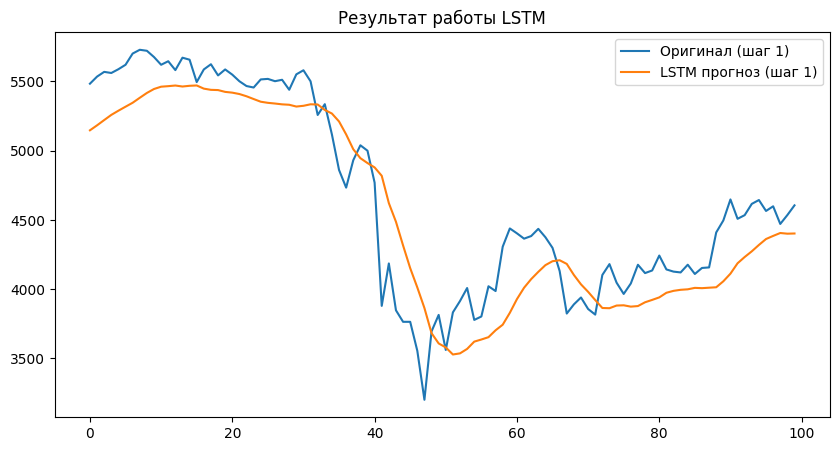

In [4]:
def build_lstm_forecaster(window, horizon):
    model = Sequential([
        LSTM(64, input_shape=(window, 1), return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

# Для сравнения выводится первый шаг прогноза из десяти
def show_lstm_result(real_values, predicted_values):
    plt.figure(figsize=(10, 5))
    plt.plot(real_values[:100, 0], label='Оригинал (шаг 1)')
    plt.plot(predicted_values[:100, 0], label='LSTM прогноз (шаг 1)')
    plt.title('Результат работы LSTM')
    plt.legend()
    plt.show()

model_lstm = build_lstm_forecaster(win_len, future_steps)

model_lstm.fit(
    x_train_10[:train_len],
    y_train_10[:train_len],
    epochs=15,
    batch_size=32
)

pred_lstm = model_lstm.predict(x_train_10[train_len:])
pred_lstm_rescaled = scaler.inverse_transform(pred_lstm)

show_lstm_result(true_10_rescaled, pred_lstm_rescaled)